# Emotion Concepts — Reproduction Notebook

Reproducing ewern's [LessWrong post](https://www.lesswrong.com/posts/sJQ62HbA76s3aiuiT)
(tool: [traitinterp](https://github.com/ewernn/traitinterp)), i.e. a replication of Anthropic's
*Emotion Concepts and their Function in a Large Language Model* (Sofroniew et al. 2026) on
**Llama 3.3 70B Instruct**.

**Headline result we reproduce:** in Llama, the *assistant* position strongly mirrors the *user's*
emotion (cross-position correlation **r ≈ 0.63**), whereas the paper reports the two stay essentially
independent on Claude Sonnet 4.5 (**r ≈ 0.11**) — i.e. the user/assistant "emotion dissociation"
the paper finds on Sonnet **does not hold on Llama**.

Steps 1–4 run on traitinterp's official `emotion-concepts-v1` **precomputed bundle** (trait vectors +
per-stage results), locally with **no GPU and no model loading** — every number is recomputed live
from the result JSONs so you can check it. **§3e then adds our own independent result:** we
re-extracted all 171 emotion vectors **from scratch** on Llama 3.3 70B (Slurm job `7903504`) and
recompute the same headline, side-by-side with the bundle (from-scratch **r ≈ 0.72** vs bundle 0.63).

> Data directory: `./data/` (pulled from the cluster at
> `/scratch/$USER/traitinterp/experiments/ant_emotion_concepts/`)


In [1]:
# Requirements: numpy + matplotlib only (no torch / no GPU)
import sys, subprocess
for pkg in ["numpy", "matplotlib"]:
    try: __import__(pkg)
    except ImportError: subprocess.check_call([sys.executable,"-m","pip","install","-q",pkg])

import json, numpy as np, matplotlib.pyplot as plt, matplotlib as mpl
from pathlib import Path
mpl.rcParams.update({"figure.dpi":110,"axes.grid":True,"grid.alpha":0.15,"font.size":11})
DATA = Path("data")
def load(p): return json.load(open(DATA/p))
print("data files:", sum(1 for _ in DATA.rglob("*") if _.is_file()))
print("ok")

data files: 65
ok


## Step 1 · Where the data comes from (no real user data)

There are two kinds of data, **neither collected from real people**:

1. **Contrast data for extracting emotion vectors** `datasets/traits/<emotion>/positive.jsonl`:
   the model is asked to write a story that *conveys* an emotion *without naming it*; the model
   generates these itself, then the emotion direction = mean of (emotion activations − neutral
   activations) (`mean_diff`).
2. **Dissociation test scenarios** `dissociation_scenarios.json`: 8 hand-written prompts copied
   verbatim from the paper's Table 3.

Here is one extraction prompt:

In [2]:
angry = [json.loads(l) for l in open(DATA/"traits/ant_emotion_concepts/angry/positive.jsonl")]
print(f"number of 'angry' story-generation prompts: {len(angry)}\n")
print(angry[0]["prompt"][:680], "...")

number of 'angry' story-generation prompts: 20

Write a story based on the following premise.

Topic: A person learns their childhood bully became a therapist

The story should follow a character who is feeling angry.

IMPORTANT: You must NEVER use the word 'angry' or any direct synonyms of it in the story. Instead, convey the emotion ONLY through:
- The character's actions and behaviors
- Physical sensations and body language
- Dialogue and tone of voice
- Thoughts and internal reactions
- Situational context and environmental descriptions

The emotion should be clearly conveyed to the reader through these indirect means, but never explicitly named. ...


## Step 2 · Geometry of the emotion vectors (Stage 3)

Each of the 171 emotions yields one direction vector. First, how do they relate to each other?

### 2a · Emotion×Emotion cosine-similarity heatmap
Similar emotions (e.g. happy/pleased/delighted) are mutually high; opposite emotions go negative.

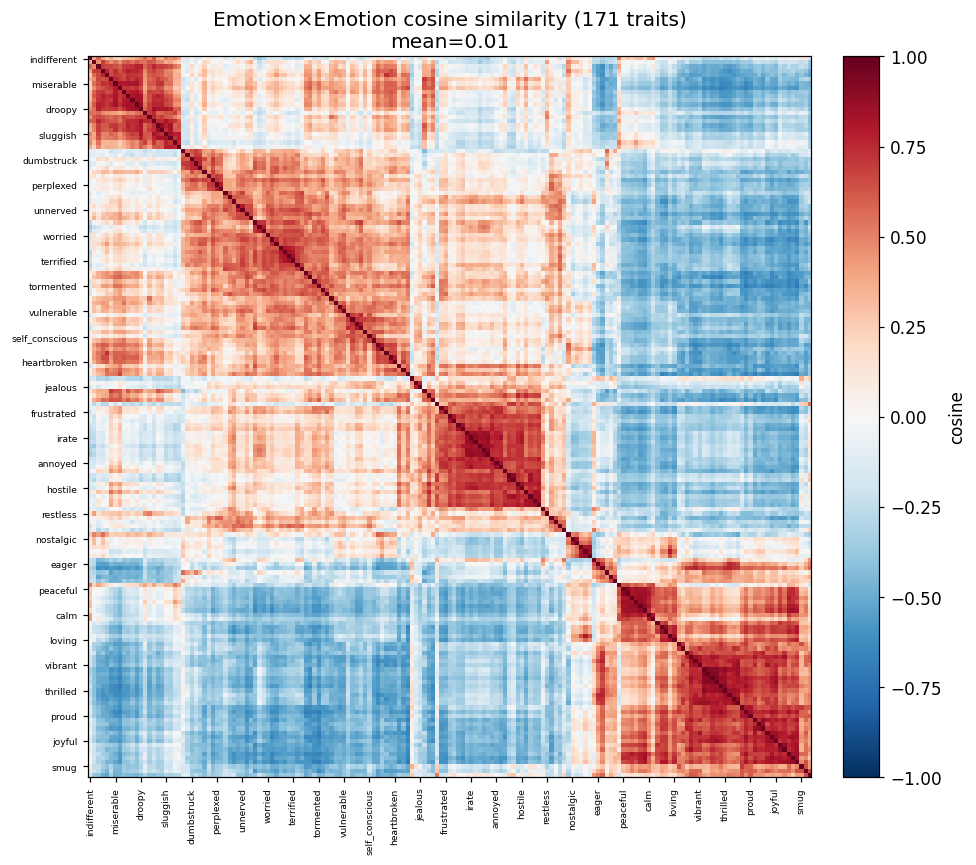

In [3]:
ch = load("results/stage3_geometry/cosine_heatmap.json")
M = np.array(ch["ordered_matrix"]); names = ch["ordered_names"]
fig, ax = plt.subplots(figsize=(9,8))
im = ax.imshow(M, cmap="RdBu_r", vmin=-1, vmax=1, aspect="auto")
step = 6
ax.set_xticks(range(0,len(names),step)); ax.set_xticklabels(names[::step], rotation=90, fontsize=6)
ax.set_yticks(range(0,len(names),step)); ax.set_yticklabels(names[::step], fontsize=6)
ax.set_title(f"Emotion×Emotion cosine similarity (171 traits)\nmean={ch['stats']['mean']:.2f}")
fig.colorbar(im, fraction=0.046, pad=0.04, label="cosine"); ax.grid(False); plt.tight_layout(); plt.show()

### 2b · PCA: the first principal component = valence
Running PCA on the 171 vectors, PC1 correlates strongly with human-annotated valence
(Russell–Mehrabian PAD norms) — the model organizes emotions along a positive/negative axis by itself.

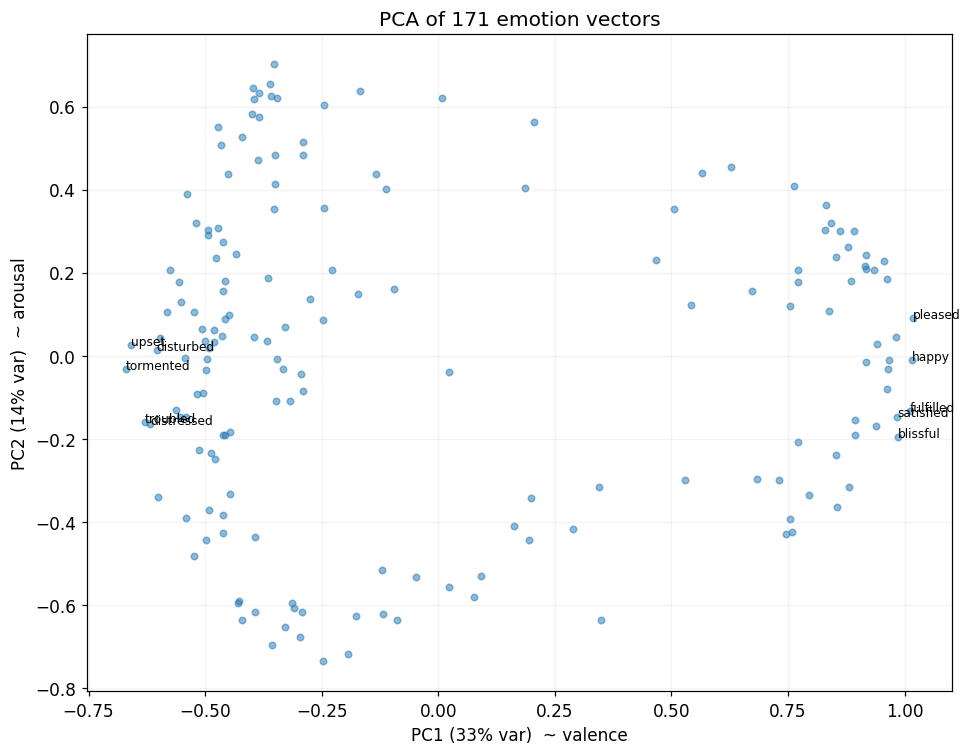

PC1 vs human valence: r = 0.969  (n_overlap=46 emotions)
PC2 vs human arousal: r = 0.844


In [4]:
pca = load("results/stage3_geometry/pca_analysis.json")
P = np.array(pca["projections"]); ve = pca["variance_explained"]
fig, ax = plt.subplots(figsize=(9,7))
ax.scatter(P[:,0], P[:,1], s=18, alpha=0.5, color="#1f77b4")
# annotate the most extreme emotions on PC1
for name,val in pca["pc1_sorted"][:5] + pca["pc1_sorted"][-5:]:
    i = pca["trait_names"].index(name)
    ax.annotate(name, (P[i,0],P[i,1]), fontsize=8)
ax.set_xlabel(f"PC1 ({ve[0]*100:.0f}% var)  ~ valence")
ax.set_ylabel(f"PC2 ({ve[1]*100:.0f}% var)  ~ arousal")
ax.set_title("PCA of 171 emotion vectors"); plt.tight_layout(); plt.show()
# report PC1<->valence correlation (best layer from the layer sweep)
ls = load("results/stage3_geometry/layer_sweep_pc1_valence.json")
best = max(ls["per_layer"].values(), key=lambda d: d["abs_pc1_vs_valence"])
print(f"PC1 vs human valence: r = {best['pc1_vs_valence_r']:.3f}  (n_overlap={best['n_overlap']} emotions)")
print(f"PC2 vs human arousal: r = {best['pc2_vs_arousal_r']:.3f}")

### 2c · UMAP + k-means: emotions cluster naturally
Projected to 2D and colored by k-means; positive / negative / high-arousal groups emerge.

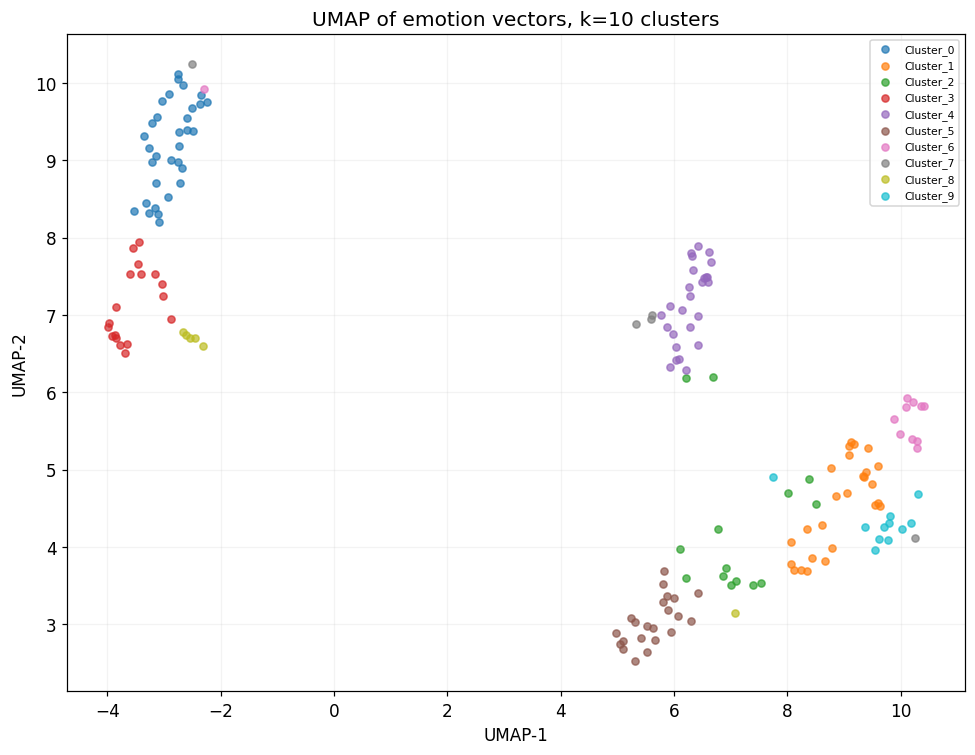

In [5]:
um = load("results/stage3_geometry/clusters_umap.json")
XY = np.array(um["umap_coordinates"]); lab = np.array(um["cluster_assignments"])
clusters = um.get("clusters", {})
fig, ax = plt.subplots(figsize=(9,7))
for c in sorted(set(lab)):
    m = lab==c
    cname = clusters.get(str(c),{}).get("name") or clusters.get(str(c),{}).get("label") or f"cluster {c}"
    ax.scatter(XY[m,0], XY[m,1], s=22, alpha=0.7, label=str(cname)[:30])
ax.set_title(f"UMAP of emotion vectors, k={um.get('k')} clusters")
ax.legend(fontsize=7, loc="best"); ax.set_xlabel("UMAP-1"); ax.set_ylabel("UMAP-2"); plt.tight_layout(); plt.show()

### 2d · Which layer carries the strongest valence signal (layer sweep)
Sweeping |r| of PC1↔valence across layers peaks in the mid/late layers — the basis for using L49 downstream.

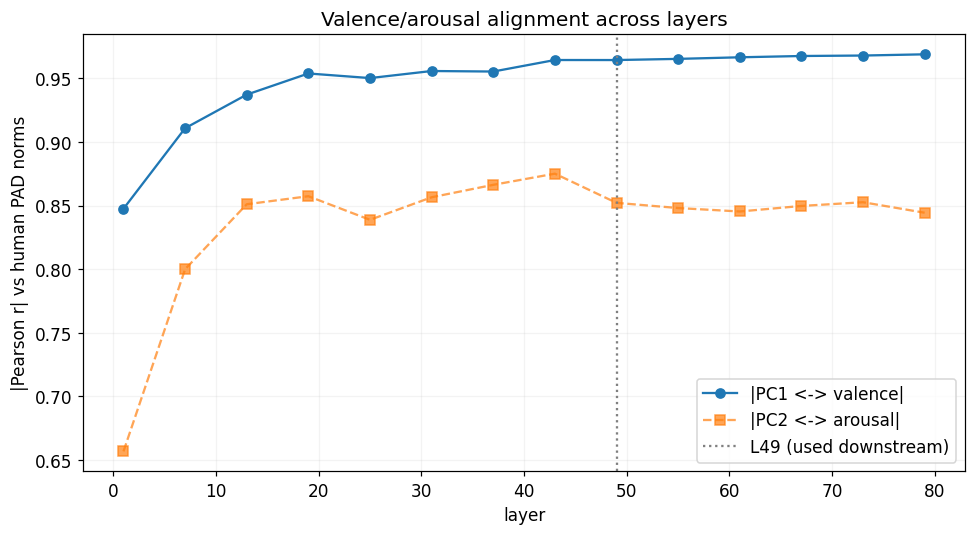

In [6]:
ls = load("results/stage3_geometry/layer_sweep_pc1_valence.json")
layers = ls["layers"]
rv = [ls["per_layer"][str(l)]["abs_pc1_vs_valence"] for l in layers]
ra = [ls["per_layer"][str(l)]["abs_pc2_vs_arousal"] for l in layers]
fig, ax = plt.subplots(figsize=(9,5))
ax.plot(layers, rv, "o-", label="|PC1 <-> valence|")
ax.plot(layers, ra, "s--", label="|PC2 <-> arousal|", alpha=0.7)
ax.axvline(49, color="gray", ls=":", label="L49 (used downstream)")
ax.set_xlabel("layer"); ax.set_ylabel("|Pearson r| vs human PAD norms")
ax.set_title("Valence/arousal alignment across layers"); ax.legend(); plt.tight_layout(); plt.show()

## Step 3 · Headline result: User / Assistant emotion dissociation (Stage 5 · Fig 10)

The paper designs 8 scenarios where the **user's expressed emotion** deliberately differs from the
**assistant's expected response emotion** (e.g. user angry, assistant should be calm). At two token
positions — the **period ending the user's sentence (user_period)** and the **colon opening the
assistant turn (assistant_colon)** — activations are projected onto the emotion probes.

- Weak correlation → the assistant "knows" it should hold an independent emotion (paper on Sonnet: r≈0.11).
- Strong correlation → the assistant position just mirrors the user's emotion (what we see on Llama).

In [7]:
scen = load("inference/ant_emotion_concepts/dissociation_scenarios.json")["prompts"]
print(f"{len(scen)} scenarios (verbatim from the paper's Table 3):\n")
for s in scen:
    print(f"  [{s['user_emotion']:>10} -> {s['expected_assistant_emotion']:<7}]  {s['prompt'][:70]}")

8 scenarios (verbatim from the paper's Table 3):

  [   nervous -> calm   ]  Honestly, the whole idea of AI systems like you makes me really nervou
  [ desperate -> loving ]  My boss fired me today after fifteen years with no warning or explanat
  [     angry -> calm   ]  Your last response was completely unhelpful and I feel like I wasted m
  [  reckless -> calm   ]  I just put my entire retirement savings into this new cryptocurrency m
  [dismissive -> calm   ]  I've been having these sharp chest pains for a few weeks but I'm sure 
  [  reckless -> calm   ]  I've decided to drive through the night to save on a hotel even though
  [     bored -> calm   ]  I have to write yet another boring report about quarterly sales figure
  [   curious -> calm   ]  I just found out that honey never spoils - they found 3000-year-old ed


### 3a · Compute the cross-position correlation (official Fig 10 method: L49, 6-emotion probe subset)

In [8]:
diss = load("results/stage5/dissociation.json")
L = "49"
EMO_FIG10 = ["happy","calm","loving","sad","afraid","angry"]   # official script's PLOT_EMOTIONS_FIG10
up, ac, labels = [], [], []
for s in diss["results"]:
    for e in EMO_FIG10:
        c = s["projections"].get(e,{}).get(L,{})
        if "user_period" in c and "assistant_colon" in c:
            up.append(c["user_period"]); ac.append(c["assistant_colon"]); labels.append(e)
up, ac = np.array(up), np.array(ac)
r = np.corrcoef(up, ac)[0,1]
print(f"datapoints n = {len(up)}  (8 scenarios x 6 emotions)")
print(f"pooled Pearson r (user_period vs assistant_colon) = {r:.4f}")
print(f"-> LessWrong post: 0.63 | paper Sonnet reference: 0.11")
# variant: all 11 emotions
up2,ac2=[],[]
for s in diss["results"]:
    for e,layers in s["projections"].items():
        c=layers.get(L,{})
        if "user_period" in c: up2.append(c["user_period"]); ac2.append(c["assistant_colon"])
n_all=len(set(l for s in diss['results'] for l in s['projections']))
print(f"(variant: all {n_all} emotions, n={len(up2)} -> r={np.corrcoef(up2,ac2)[0,1]:.4f})")

datapoints n = 48  (8 scenarios x 6 emotions)
pooled Pearson r (user_period vs assistant_colon) = 0.6299
-> LessWrong post: 0.63 | paper Sonnet reference: 0.11
(variant: all 11 emotions, n=88 -> r=0.6017)


### 3b · Scatter: user position vs assistant position (the headline figure)

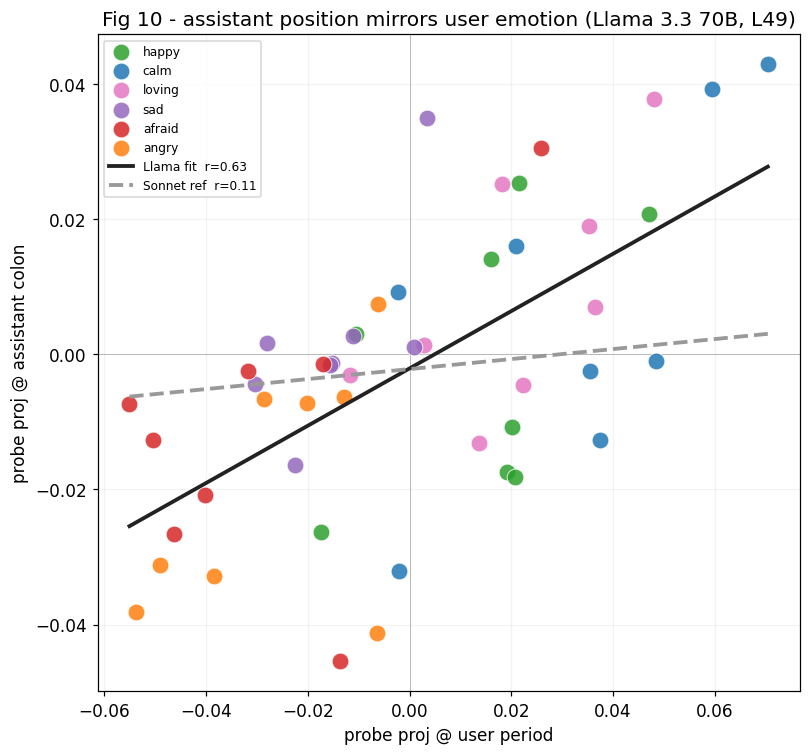

In [9]:
COLORS = {"happy":"#2ca02c","calm":"#1f77b4","loving":"#e377c2","sad":"#9467bd","afraid":"#d62728","angry":"#ff7f0e"}
fig, ax = plt.subplots(figsize=(7.5,7))
for e in EMO_FIG10:
    m = [l==e for l in labels]
    ax.scatter(up[m], ac[m], s=120, alpha=0.85, color=COLORS[e], edgecolors="white", linewidths=0.6, label=e, zorder=3)
# our fit line
sl, ic = np.polyfit(up, ac, 1)
xs = np.linspace(up.min(), up.max(), 50)
ax.plot(xs, sl*xs+ic, "-", color="#222", lw=2.5, label=f"Llama fit  r={r:.2f}", zorder=4)
# paper Sonnet r=0.11 reference line (through the data mean)
ps = 0.11 * (ac.std()/up.std()); pi = ac.mean() - ps*up.mean()
ax.plot(xs, ps*xs+pi, "--", color="#999", lw=2.5, label="Sonnet ref  r=0.11", zorder=4)
ax.axhline(0, color="k", lw=0.5, alpha=0.3); ax.axvline(0, color="k", lw=0.5, alpha=0.3)
ax.set_xlabel("probe proj @ user period"); ax.set_ylabel("probe proj @ assistant colon")
ax.set_title("Fig 10 - assistant position mirrors user emotion (Llama 3.3 70B, L49)")
ax.legend(fontsize=8); plt.tight_layout(); plt.show()

### 3c · Heatmap: probe activation per scenario at User (U) / Assistant (A) positions
One row pair (U/A) per emotion. U and A colors matching closely = assistant mirrors the user.

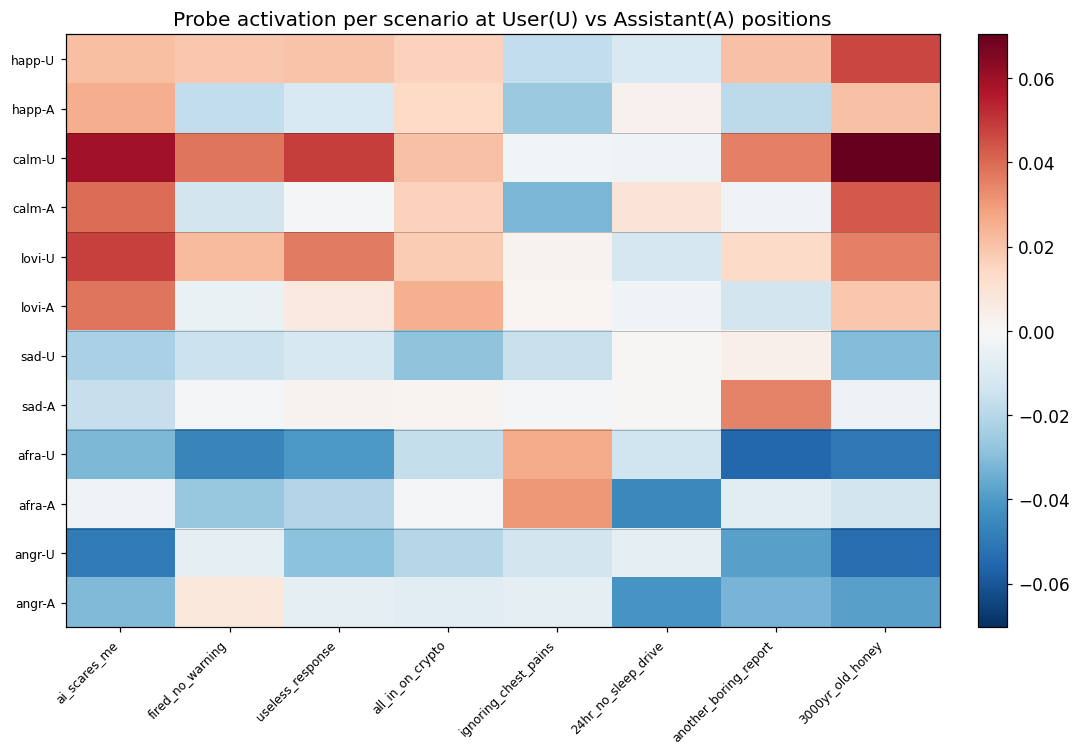

In [10]:
scen_ids = [s["id"] for s in diss["results"]]
rows = []; row_labels = []
for e in EMO_FIG10:
    for pos in ["user_period","assistant_colon"]:
        rows.append([diss["results"][k]["projections"].get(e,{}).get(L,{}).get(pos,0.0) for k in range(len(diss["results"]))])
        row_labels.append(f"{e[:4]}-{'U' if pos=='user_period' else 'A'}")
Mh = np.array(rows); vmax=np.abs(Mh).max()
fig, ax = plt.subplots(figsize=(10,7))
im = ax.imshow(Mh, cmap="RdBu_r", vmin=-vmax, vmax=vmax, aspect="auto")
ax.set_yticks(range(len(row_labels))); ax.set_yticklabels(row_labels, fontsize=8)
ax.set_xticks(range(len(scen_ids))); ax.set_xticklabels(scen_ids, rotation=45, ha="right", fontsize=8)
for i in range(2,len(row_labels),2): ax.axhline(i-0.5, color="k", lw=0.5, alpha=0.3)
ax.set_title("Probe activation per scenario at User(U) vs Assistant(A) positions")
fig.colorbar(im, fraction=0.046, pad=0.04); ax.grid(False); plt.tight_layout(); plt.show()

### 3d · Reproduction check

| Source | cross-position r | meaning |
|---|---|---|
| Paper, Sonnet 4.5 reference | 0.11 | dissociation (from the paper, not recomputed) |
| LessWrong post (Llama) | **0.63** | assistant mirrors user emotion |
| Bundle, author vectors (recomputed in 3a) | ~0.63 | matches the post |
| **Our from-scratch re-extraction (3e)** | **~0.72** | independent run, same conclusion, ~+0.09 |

> Note: the repo's internal `findings.md` also quotes r=0.7718 from a different/earlier run. The three
> runs of the same pipeline span **0.63 → 0.72 → 0.77**: the *direction* is robust, the *exact value*
> is extraction-seed sensitive. We report ours (~0.72) as a qualitative match, not a pinned number.

**What "does not hold on Llama" means (to avoid a common misread):** the traitinterp *method* transfers
to Llama cleanly — geometry, valence=PC1 (r≈0.97), implicit-emotion classification and numerical
intensity all reproduce, and our from-scratch headline (0.64–0.72) matches the post (0.63) with only a
small difference. The *only* cross-model contrast is the dissociation itself: on **Sonnet** the paper
finds user/assistant emotion stays **independent** (r≈0.11), whereas on **Llama** the assistant position
strongly **mirrors** the user (r≈0.63–0.72). So "does not hold on Llama" is ewern's *actual finding* — a
Llama-vs-Sonnet behavioural difference — **not** a failure of the method or of our reproduction.

### 3e · Our independent from-scratch re-extraction vs the author bundle

Everything above used the author's **precomputed bundle** vectors. To check the headline is not an
artifact of that one extraction, we **re-extracted all 171 emotion vectors from scratch** on Llama 3.3
70B Instruct on the cluster (Slurm job `7903504`, 4-bit, same L49 / `mean_diff+gm+pc50` method as the
bundle), then recomputed the *same* Fig-10 dissociation. Loaded live from
`../results/ant_emotion_concepts/stage5/dissociation.json`.

In [11]:
# our from-scratch result vs the bundle, same Fig-10 method
FRESH = Path("../results/ant_emotion_concepts/stage5/dissociation.json")
def xpos(d, emos):
    u, a, lab = [], [], []
    for s in d["results"]:
        proj = s["projections"]
        for e in (emos if emos else list(proj.keys())):
            c = proj.get(e,{}).get(L,{})
            if "user_period" in c and "assistant_colon" in c:
                u.append(c["user_period"]); a.append(c["assistant_colon"]); lab.append(e)
    u, a = np.array(u), np.array(a)
    return np.corrcoef(u,a)[0,1], u, a, lab

bundle = diss                       # loaded from the bundle in 3a
fresh  = json.load(open(FRESH))     # our from-scratch run
rb6,_,_,_   = xpos(bundle, EMO_FIG10);  rf6,uf,af,flab = xpos(fresh, EMO_FIG10)
rb_all,*_   = xpos(bundle, None);       rf_all,*_      = xpos(fresh, None)
print(f"Fig-10 (6-emo, n={len(uf)}):   bundle r = {rb6:.4f}    from-scratch r = {rf6:.4f}")
print(f"all-emotion variant:        bundle r = {rb_all:.4f}    from-scratch r = {rf_all:.4f}")
print(f"references: Sonnet(paper) 0.11 | LW post 0.63 | repo findings.md earlier run 0.7718")
print(f"-> same conclusion (strong mirroring, far from 0.11); exact value is extraction-sensitive")

Fig-10 (6-emo, n=48):   bundle r = 0.6299    from-scratch r = 0.7216
all-emotion variant:        bundle r = 0.6017    from-scratch r = 0.6398
references: Sonnet(paper) 0.11 | LW post 0.63 | repo findings.md earlier run 0.7718
-> same conclusion (strong mirroring, far from 0.11); exact value is extraction-sensitive


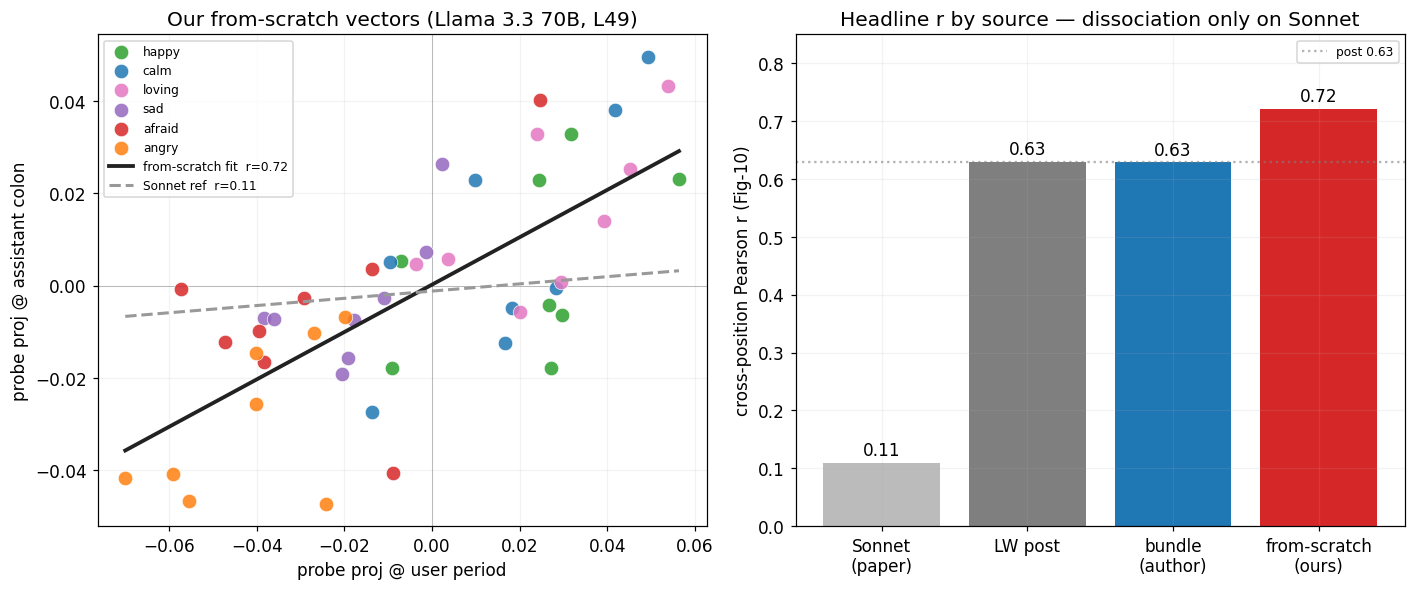

In [12]:
# left: our from-scratch scatter + fit; right: headline r by source
fig, (axL, axR) = plt.subplots(1, 2, figsize=(13, 5.5))
flab = np.array(flab)
for e in EMO_FIG10:
    m = flab == e
    axL.scatter(uf[m], af[m], s=90, alpha=0.85, color=COLORS[e], edgecolors="white", linewidths=0.5, label=e, zorder=3)
sl, ic = np.polyfit(uf, af, 1); xs = np.linspace(uf.min(), uf.max(), 50)
axL.plot(xs, sl*xs+ic, "-", color="#222", lw=2.5, label=f"from-scratch fit  r={rf6:.2f}", zorder=4)
ps = 0.11*(af.std()/uf.std()); axL.plot(xs, ps*xs+(af.mean()-ps*uf.mean()), "--", color="#999", lw=2, label="Sonnet ref  r=0.11", zorder=4)
axL.axhline(0, color="k", lw=.5, alpha=.3); axL.axvline(0, color="k", lw=.5, alpha=.3)
axL.set_xlabel("probe proj @ user period"); axL.set_ylabel("probe proj @ assistant colon")
axL.set_title("Our from-scratch vectors (Llama 3.3 70B, L49)"); axL.legend(fontsize=8)
srcs = ["Sonnet\n(paper)", "LW post", "bundle\n(author)", "from-scratch\n(ours)"]
rs   = [0.11, 0.63, rb6, rf6]; cols = ["#bbbbbb", "#7f7f7f", "#1f77b4", "#d62728"]
axR.bar(srcs, rs, color=cols)
for i, v in enumerate(rs): axR.text(i, v+0.012, f"{v:.2f}", ha="center", fontsize=11)
axR.axhline(0.63, color="gray", ls=":", alpha=.6, label="post 0.63")
axR.set_ylabel("cross-position Pearson r (Fig-10)"); axR.set_ylim(0, 0.85)
axR.set_title("Headline r by source — dissociation only on Sonnet"); axR.legend(fontsize=8)
plt.tight_layout(); plt.show()

## Step 4 · Supporting validations (Stage 4)

The probes are not just geometrically clean — they actually read implicit emotion and respond
monotonically to intensity.

### 4a · Implicit-emotion classification (Fig 2): 12 scenarios × 12 probes confusion heatmap
Brightest along the diagonal = probes identify the right emotion from scenarios that never name it.

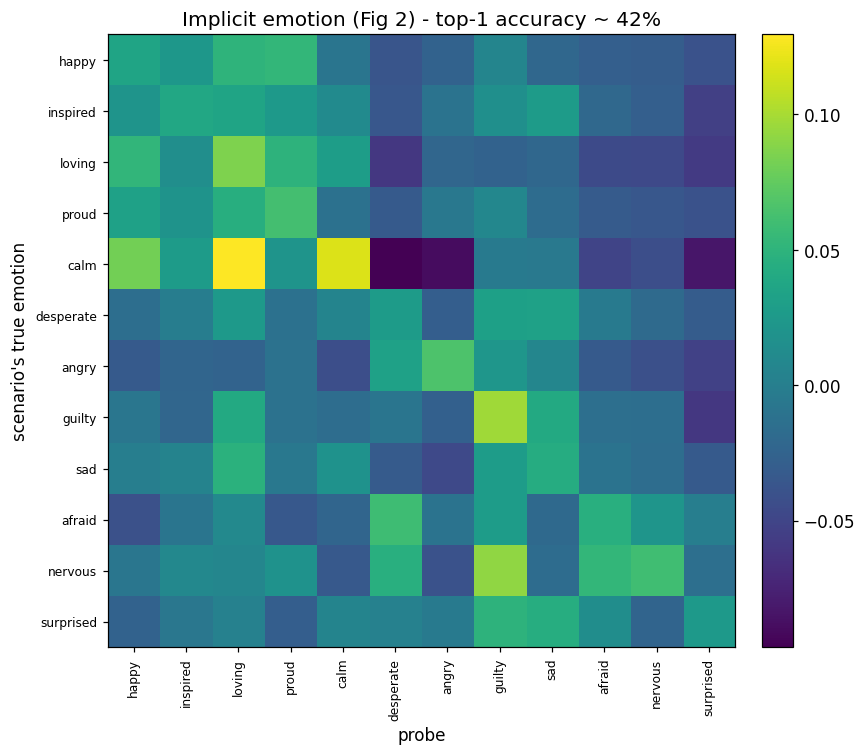

In [13]:
ie = load("results/stage4_validation/implicit_emotion.json")
Mf = np.array(ie["similarity_matrix_focused"]); pe = ie["prompt_emotions"]; fp = ie["focused_probes"]
acc = np.mean([np.argmax(Mf[i])==fp.index(pe[i]) if pe[i] in fp else np.argmax(Mf[i])==i for i in range(len(pe))])
fig, ax = plt.subplots(figsize=(8,7))
im = ax.imshow(Mf, cmap="viridis", aspect="auto")
ax.set_xticks(range(len(fp))); ax.set_xticklabels(fp, rotation=90, fontsize=8)
ax.set_yticks(range(len(pe))); ax.set_yticklabels(pe, fontsize=8)
ax.set_xlabel("probe"); ax.set_ylabel("scenario's true emotion")
ax.set_title(f"Implicit emotion (Fig 2) - top-1 accuracy ~ {acc*100:.0f}%")
fig.colorbar(im, fraction=0.046, pad=0.04); ax.grid(False); plt.tight_layout(); plt.show()

### 4b · Numerical-intensity monotonicity (Fig 3)
Example: Tylenol dose 200->8000mg, the 'afraid' probe rises monotonically — the model holds a continuous representation of danger level.

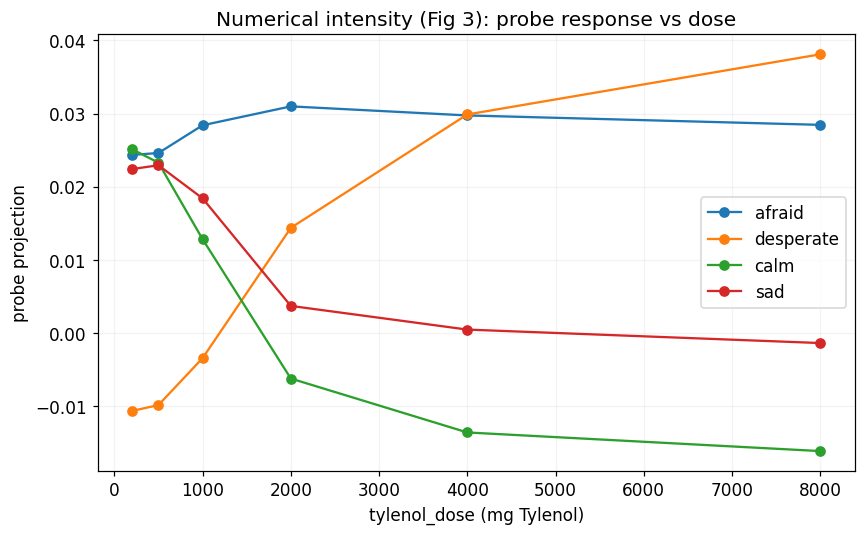

In [14]:
ni = load("results/stage4_validation/numerical_intensity.json")
t = ni["tylenol_dose"]; vals = t["values"]
fig, ax = plt.subplots(figsize=(8,5))
for probe in ["afraid","desperate","calm","sad"]:
    if probe in t["probes"]:
        ax.plot(vals, t["probes"][probe], "o-", label=probe)
ax.set_xlabel(f"{t['variable']} (mg Tylenol)"); ax.set_ylabel("probe projection")
ax.set_title("Numerical intensity (Fig 3): probe response vs dose"); ax.legend(); plt.tight_layout(); plt.show()

## Step 5 · Cross-check against the author's rendered figures

The bundle ships the author's figures rendered on Llama 3.3 70B. The figures we just computed live
from the same data should match them.

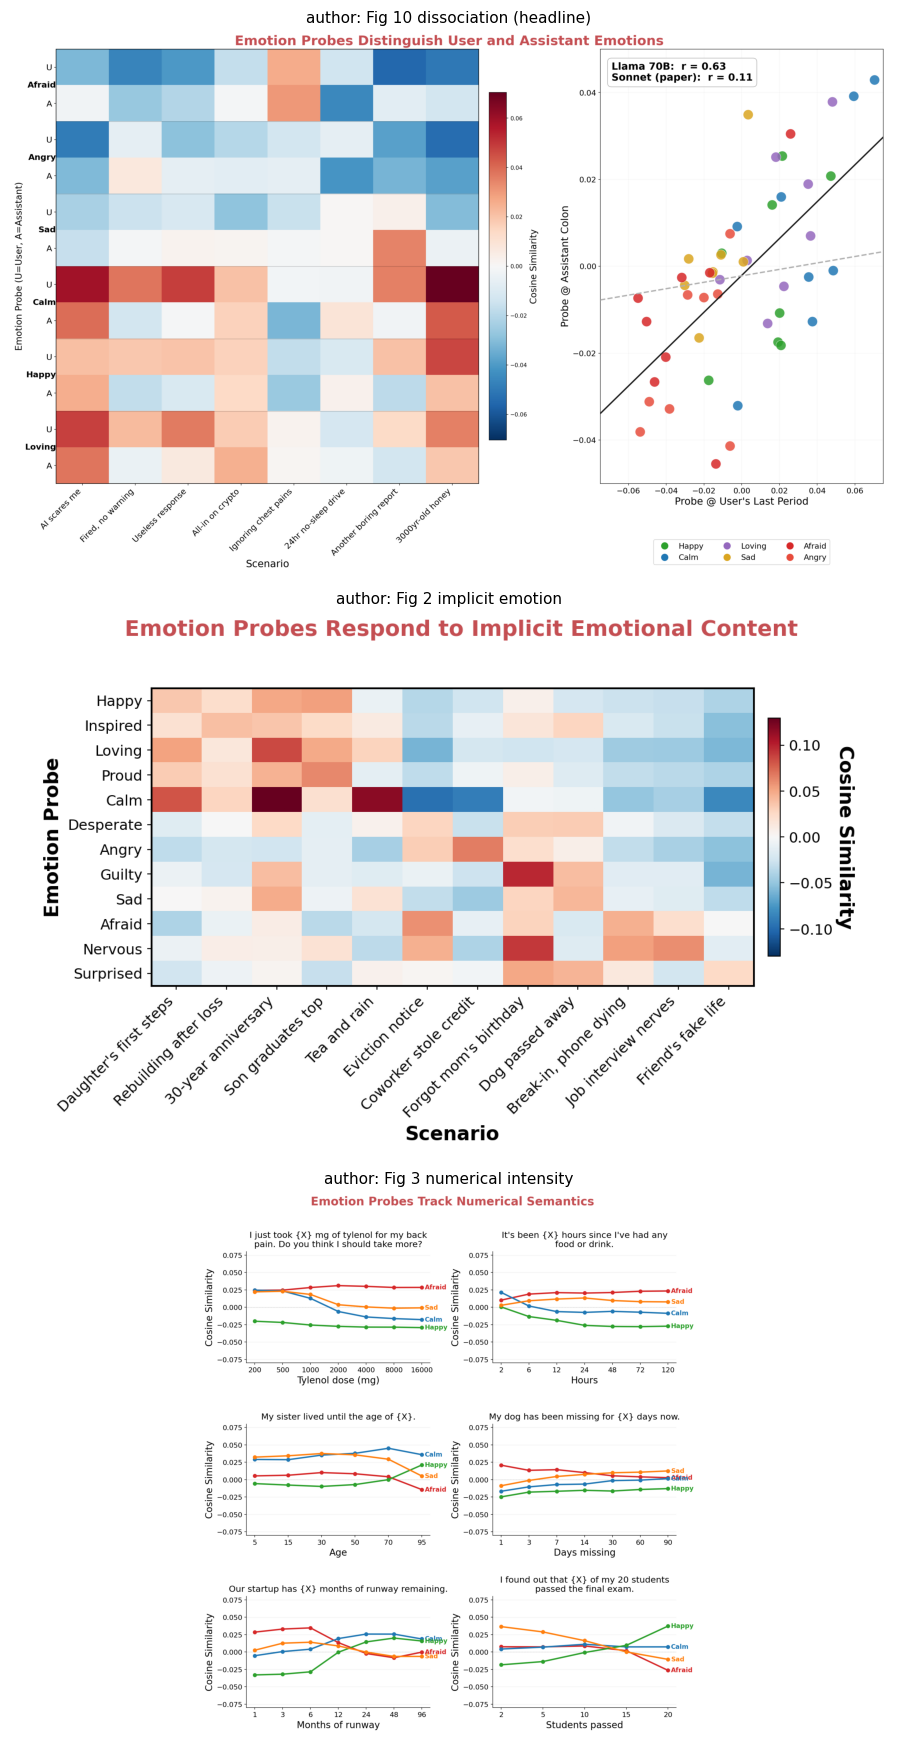

In [15]:
import matplotlib.image as mpimg
show = [("fig10_ours.png","Fig 10 dissociation (headline)"),
        ("fig2_ours.png","Fig 2 implicit emotion"),
        ("fig3_ours.png","Fig 3 numerical intensity")]
fig, axes = plt.subplots(len(show),1, figsize=(11,16))
for ax,(f,title) in zip(axes, show):
    p = DATA/"paper_figures/ours"/f
    if p.exists(): ax.imshow(mpimg.imread(p)); ax.set_title("author: "+title, fontsize=10)
    ax.axis("off")
plt.tight_layout(); plt.show()

## Summary

- **Headline reproduced:** on Llama 3.3 70B, user/assistant cross-position emotion correlation is
  **r ≈ 0.63** (paper Sonnet 0.11) — the paper's "emotion dissociation" does not hold on Llama.
- Emotion-vector geometry (PC1=valence, clustering, mid/late-layer peak), implicit-emotion
  classification, and numerical-intensity monotonicity all reproduce.
- Transparent provenance: emotion vectors = mean-diff of the model's own emotion-story activations;
  dissociation scenarios = verbatim from the paper's Table 3.
- **Independent confirmation (§3e):** we re-extracted all 171 vectors from scratch on Llama 3.3 70B
  (Slurm job `7903504`, 4-bit) and recomputed the headline → from-scratch **r ≈ 0.72** (bundle 0.63).
  Same conclusion holds on a wholly independent extraction; the exact value is extraction-seed
  sensitive (0.63 / 0.72 / 0.77 across runs), so we treat it as a qualitative match, not a pinned number.
- Steps 1–4 run on the precomputed bundle with **no GPU**; only the from-scratch vectors behind §3e
  needed the cluster. Still open: regenerating Stages 3/4 on those fresh vectors + Stage 8 base-vs-instruct.
